In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, r2_score
from sklearn.preprocessing import StandardScaler

In [18]:
df = pd.read_csv("Social_Network_Ads.csv")

In [19]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [21]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [22]:
X = df[['Age','EstimatedSalary']]
y = df['Purchased']

In [52]:
X = df[['Age', 'EstimatedSalary']]

y = df['Purchased']

display(X.head())
display(y.head())     

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
   X,y,test_size=0.25,random_state=0
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (300, 2)
Testing size: (100, 2)


In [67]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [68]:
model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [69]:
y_pred = model.predict(X_test)

In [72]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[65,  3],
       [ 8, 24]])

In [74]:
TN =cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]

print("TN :",TN)
print("FP :",FP)
print("FN :",FN)
print("TP :",TP)

TN : 65
FP : 3
FN : 8
TP : 24


In [77]:
sum_all = TP + TN + FP + FN

accuracy = (TP + TN)/(TP + TN + FP + FN)

error_rate = (FP + FN)/(TP + TN + FP + FN)

precision = TP/(TP+FP)

recall = TP/(TP + FN)

print("accuracy = (TP + TN)/(TP + TN + FP + FN) : ",accuracy)
print("error_rate = (FP + FN)/(TP+TN+FP+FN) : ",error_rate)
print("precision = TP/(TP + FP) : ",precision)
print("recall = TP/(TP + FN) : ",recall)

accuracy = (TP + TN)/(TP + TN + FP + FN) :  0.89
error_rate = (FP + FN)/(TP+TN+FP+FN) :  0.11
precision = TP/(TP + FP) :  0.8888888888888888
recall = TP/(TP + FN) :  0.75


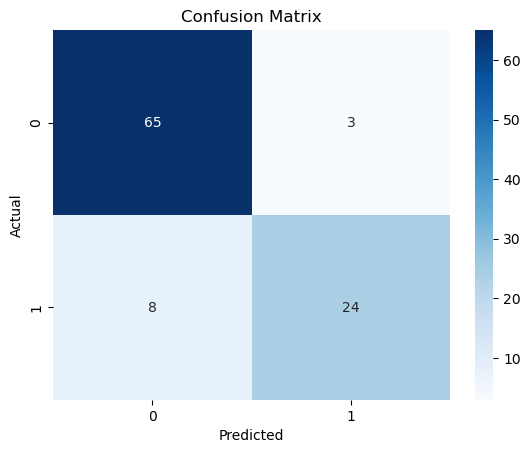

In [83]:
sns.heatmap(cm,annot=True,cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()